In [1]:
# Cell 1
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import AutoImageProcessor, AutoModel

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 1b
# ==== CONFIG ====
DATA_DIR = Path("v18/train")   # folder containing .npy files + annotations.json
ANNOT_PATH = DATA_DIR / "annotations.json"

MODEL_NAME = "facebook/dinov2-base"       # can switch to large if you want
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 32
NUM_WORKERS = 4

# Which DINO summary to use:
# "cls"        -> CLS token only
# "mean_patch" -> average over patch tokens
# "concat"     -> concat(CLS, mean_patch)
FEATURE_MODE = "cls"

# Counts held out from training the adapter
UNSEEN_COUNTS = {3}   # example
LEARN_BASE = True

# Residual adapter hyperparams
RANK = 128
HIDDEN = 128
EPOCHS = 400
LR = 1e-3
WEIGHT_DECAY = 1e-4

LAMBDA_L2 = 1.0
LAMBDA_COS = 0.5
LAMBDA_SMOOTH = 0.05

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
# Cell 2
with open(ANNOT_PATH, "r") as f:
    coco = json.load(f)

images_df = pd.DataFrame(coco["images"])

categories_df = pd.DataFrame(coco.get("categories", []))
person_cat_ids = set(categories_df.loc[categories_df["name"] == "person", "id"].tolist())

annotations_df = pd.DataFrame(coco.get("annotations", []))
if len(annotations_df) == 0:
    raise ValueError("No annotations found in annotations.json")

# Keep only person annotations if category_id exists
if "category_id" in annotations_df.columns and len(person_cat_ids) > 0:
    annotations_df = annotations_df[annotations_df["category_id"].isin(person_cat_ids)].copy()

# Infer count = number of person annotations per image_id
count_per_image = annotations_df.groupby("image_id").size().rename("person_count")

df = images_df.merge(
    count_per_image,
    how="left",
    left_on="id",
    right_index=True,
)

df["person_count"] = df["person_count"].fillna(0).astype(int)
df["path"] = df["file_name"].apply(lambda x: str(DATA_DIR / x))

# Keep only files that exist
df = df[df["path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

print(df.head())
print("\nCount distribution:")
print(df["person_count"].value_counts().sort_index())

                                                  id  width  height  \
0  sequence-20250506-172443-625038-ce2df7-b3a1b45...    256     192   
1  sequence-20250408-163030-309114-ce2dcd-8f5e55a...    256     192   
2  sequence-20250324-131641-706256-ce2dcd-32c6c47...    256     192   
3  sequence-20250320-144710-926129-ce2dcd-960296b...    256     192   
4  sequence-20250407-170617-139933-ce2dfd-53d63af...    256     192   

                                           file_name  person_count  \
0  sequence-20250506-172443-625038-ce2df7-b3a1b45...             2   
1  sequence-20250408-163030-309114-ce2dcd-8f5e55a...             2   
2  sequence-20250324-131641-706256-ce2dcd-32c6c47...             4   
3  sequence-20250320-144710-926129-ce2dcd-960296b...             2   
4  sequence-20250407-170617-139933-ce2dfd-53d63af...             1   

                                                path  
0  v18/train/sequence-20250506-172443-625038-ce2d...  
1  v18/train/sequence-20250408-163030-3091

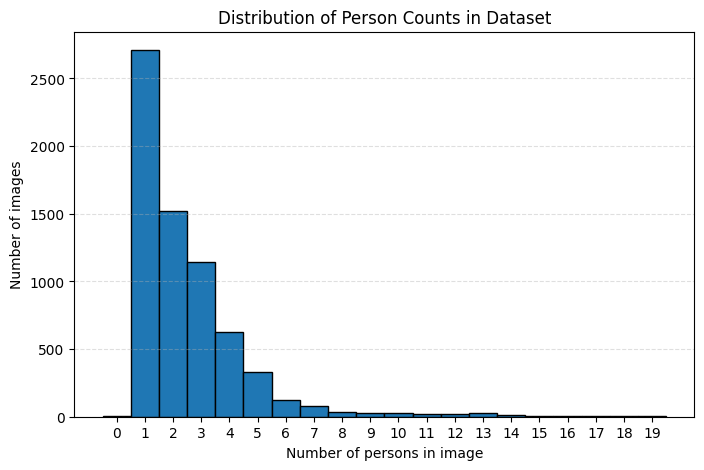

In [12]:
# Cell 3 — Histogram of person counts

import matplotlib.pyplot as plt

counts = df["person_count"]

plt.figure(figsize=(8,5))

plt.hist(
    counts,
    bins=range(counts.min(), counts.max() + 2),
    align="left",
    edgecolor="black"
)

plt.xlabel("Number of persons in image")
plt.ylabel("Number of images")
plt.title("Distribution of Person Counts in Dataset")

plt.xticks(range(counts.min(), counts.max() + 1))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

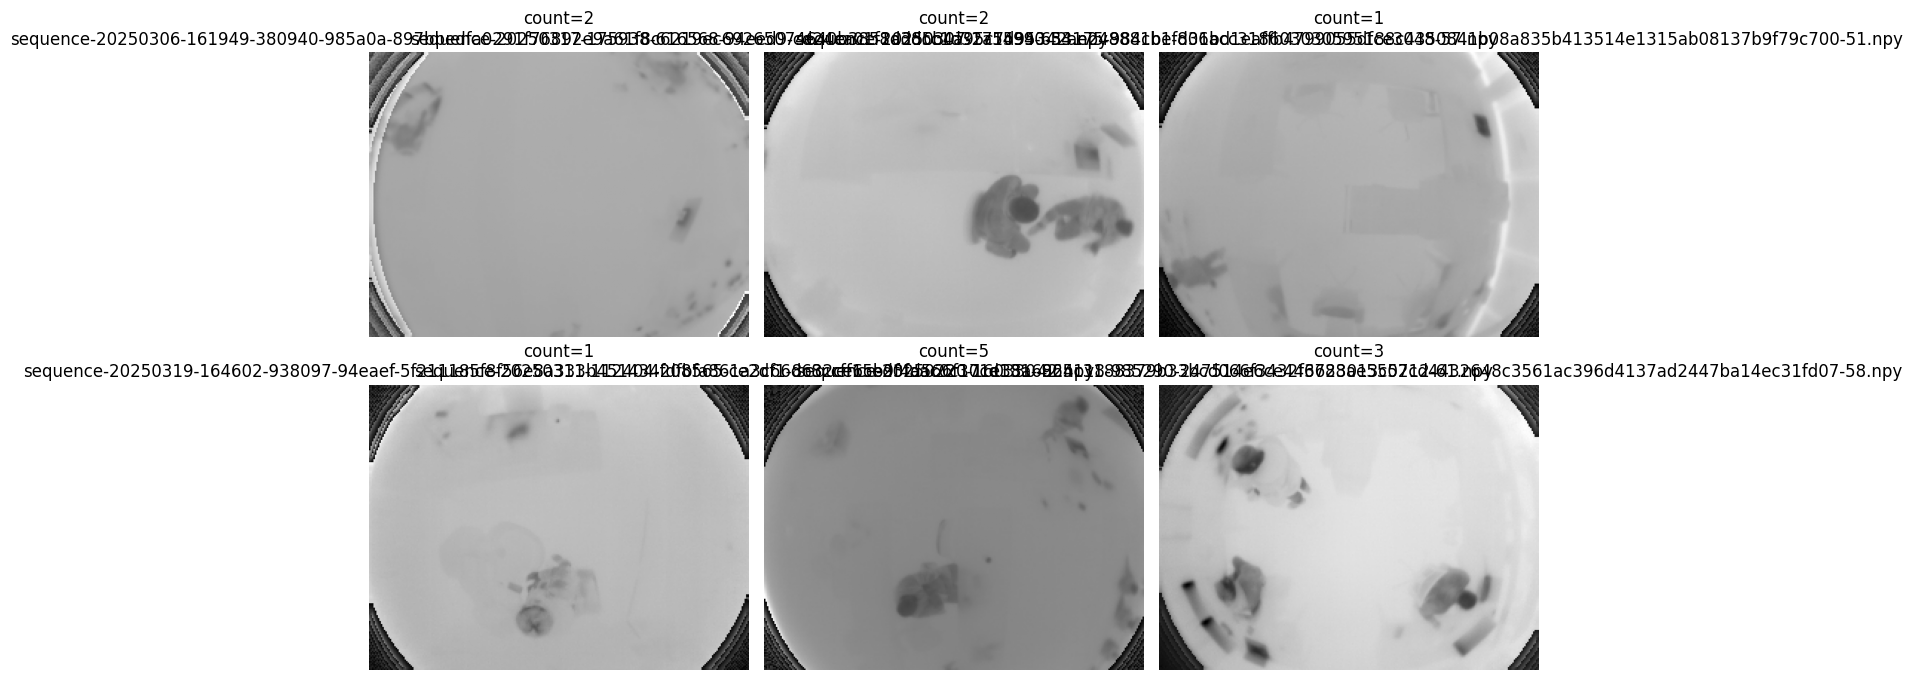

In [4]:
# Cell 3
def load_npy_image(path):
    arr = np.load(path)
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
    if arr.ndim != 2:
        raise ValueError(f"Expected HxW or HxWx1 array, got shape {arr.shape} for {path}")
    return arr

def minmax01(arr):
    arr = arr.astype(np.float32)
    mn = arr.min()
    mx = arr.max()
    if mx <= mn:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - mn) / (mx - mn)

sample_df = df.sample(min(6, len(df)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    arr = load_npy_image(row["path"])
    arr01 = minmax01(arr)
    ax.imshow(arr01, cmap="gray")
    ax.set_title(f'count={row["person_count"]}\n{Path(row["path"]).name}')
    ax.axis("off")

for ax in axes[len(sample_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Cell 4
class NpyImageDataset(Dataset):
    def __init__(self, frame_df):
        self.df = frame_df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = load_npy_image(row["path"])
        arr01 = minmax01(arr)  # H, W in [0,1]

        # H, W -> H, W, 3
        rgb = np.repeat(arr01[..., None], 3, axis=-1).astype(np.float32)

        return {
            "image": rgb,
            "count": int(row["person_count"]),
            "image_id": row["id"],
            "file_name": row["file_name"],
        }

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

print("Loaded:", MODEL_NAME)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded: facebook/dinov2-base


In [6]:
# Cell 5
def collate_fn(batch):
    images = [b["image"] for b in batch]
    counts = torch.tensor([b["count"] for b in batch], dtype=torch.long)
    image_ids = [b["image_id"] for b in batch]
    file_names = [b["file_name"] for b in batch]

    proc = processor(images=images, return_tensors="pt", do_rescale=False)
    proc["counts"] = counts
    proc["image_ids"] = image_ids
    proc["file_names"] = file_names
    return proc

dataset = NpyImageDataset(df)
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    collate_fn=collate_fn,
)

@torch.no_grad()
def extract_features(model, loader, device="cpu", feature_mode="cls"):
    all_feats = []
    all_counts = []
    all_ids = []
    all_files = []

    for batch in tqdm(loader, desc="Extracting DINO features"):
        pixel_values = batch["pixel_values"].to(device)
        outputs = model(pixel_values=pixel_values)
        hidden = outputs.last_hidden_state  # [B, 1+Npatch, D]

        cls = hidden[:, 0]          # [B, D]
        patches = hidden[:, 1:]     # [B, Npatch, D]
        mean_patch = patches.mean(dim=1)

        if feature_mode == "cls":
            feat = cls
        elif feature_mode == "mean_patch":
            feat = mean_patch
        elif feature_mode == "concat":
            feat = torch.cat([cls, mean_patch], dim=-1)
        else:
            raise ValueError(f"Unknown feature_mode={feature_mode}")

        all_feats.append(feat.cpu())
        all_counts.append(batch["counts"].cpu())
        all_ids.extend(batch["image_ids"])
        all_files.extend(batch["file_names"])

    feats = torch.cat(all_feats, dim=0).numpy()
    counts = torch.cat(all_counts, dim=0).numpy()

    out_df = pd.DataFrame({
        "image_id": all_ids,
        "file_name": all_files,
        "person_count": counts,
    })

    return feats, out_df

features, feat_df = extract_features(model, loader, device=DEVICE, feature_mode=FEATURE_MODE)
print("features shape:", features.shape)
feat_df.head()

Extracting DINO features: 100%|██████████| 211/211 [01:29<00:00,  2.36it/s]


features shape: (6725, 768)


,image_id,file_name,person_count
0,sequence-20250506-172443-625038-ce2df7-b3a1b45...,sequence-20250506-172443-625038-ce2df7-b3a1b45...,2
1,sequence-20250408-163030-309114-ce2dcd-8f5e55a...,sequence-20250408-163030-309114-ce2dcd-8f5e55a...,2
2,sequence-20250324-131641-706256-ce2dcd-32c6c47...,sequence-20250324-131641-706256-ce2dcd-32c6c47...,4
3,sequence-20250320-144710-926129-ce2dcd-960296b...,sequence-20250320-144710-926129-ce2dcd-960296b...,2
4,sequence-20250407-170617-139933-ce2dfd-53d63af...,sequence-20250407-170617-139933-ce2dfd-53d63af...,1


In [8]:
# Cell 6
feat_df = feat_df.merge(
    df[["id", "file_name", "person_count", "path"]],
    left_on=["image_id", "file_name", "person_count"],
    right_on=["id", "file_name", "person_count"],
    how="left",
).drop(columns=["id"])

feat_df["feat_idx"] = np.arange(len(feat_df))

# Prototype per count
unique_counts = sorted(feat_df["person_count"].unique().tolist())
prototypes = {}

for k in unique_counts:
    idx = feat_df.loc[feat_df["person_count"] == k, "feat_idx"].to_numpy()
    prototypes[k] = features[idx].mean(axis=0)

base_feature = features.mean(axis=0)

print("Available counts:", unique_counts)
print("Base feature shape:", base_feature.shape)
for k in unique_counts:
    n_k = (feat_df["person_count"] == k).sum()
    print(f"count={k}: n={n_k}")

Available counts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Base feature shape: (768,)
count=0: n=6
count=1: n=2710
count=2: n=1517
count=3: n=1142
count=4: n=625
count=5: n=327
count=6: n=122
count=7: n=81
count=8: n=36
count=9: n=30
count=10: n=24
count=11: n=20
count=12: n=19
count=13: n=29
count=14: n=13
count=15: n=3
count=16: n=8
count=17: n=2
count=18: n=3
count=19: n=8


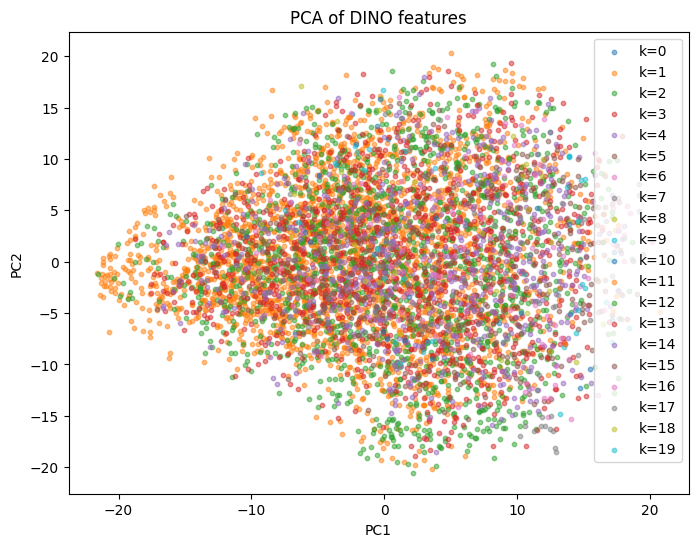

In [9]:
# Cell 7
scaler = StandardScaler()
features_std = scaler.fit_transform(features)

pca = PCA(n_components=2, random_state=SEED)
proj = pca.fit_transform(features_std)

plot_df = feat_df.copy()
plot_df["pc1"] = proj[:, 0]
plot_df["pc2"] = proj[:, 1]

plt.figure(figsize=(8, 6))
for k in sorted(plot_df["person_count"].unique()):
    sub = plot_df[plot_df["person_count"] == k]
    plt.scatter(sub["pc1"], sub["pc2"], s=10, alpha=0.5, label=f"k={k}")
plt.legend()
plt.title("PCA of DINO features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

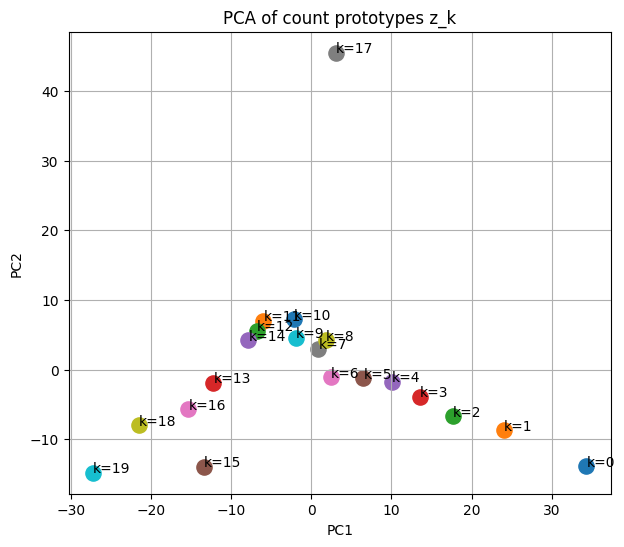

In [10]:
# Compute prototype matrix
proto_mat = np.stack([prototypes[k] for k in sorted(prototypes)], axis=0)
counts = np.array(sorted(prototypes))

# PCA on prototypes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

proto_std = StandardScaler().fit_transform(proto_mat)
pca = PCA(n_components=2)
proto_2d = pca.fit_transform(proto_std)

plt.figure(figsize=(7,6))

for i, k in enumerate(counts):
    plt.scatter(proto_2d[i,0], proto_2d[i,1], s=120)
    plt.text(proto_2d[i,0], proto_2d[i,1], f"k={k}")

plt.title("PCA of count prototypes z_k")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

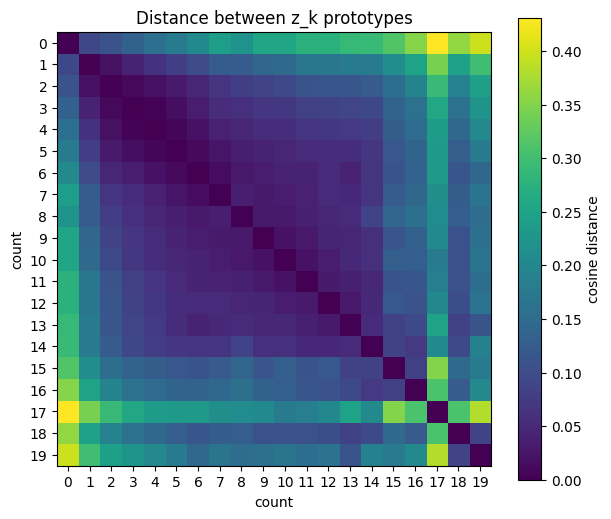

In [11]:
from scipy.spatial.distance import cdist

dist = cdist(proto_mat, proto_mat, metric="cosine")

plt.figure(figsize=(7,6))
plt.imshow(dist)
plt.colorbar(label="cosine distance")
plt.xticks(range(len(counts)), counts)
plt.yticks(range(len(counts)), counts)
plt.title("Distance between z_k prototypes")
plt.xlabel("count")
plt.ylabel("count")
plt.show()